# 분류 실습 — 어떤 예측을 바꿔보고 싶나요?

앞의 코드로 기본 모델과 결과를 준비한 뒤, AI와 대화하며 궁금한 예측을 살펴보고 개선을 시도합니다. 분석할 대상과 방법은 직접 고릅니다.

지표 설명은 [classification.ipynb](1.%20classification.ipynb)를 참고하세요.

## 1. 함께 준비 · 데이터와 기본 모델

한 행은 타이타닉 승객 한 명입니다. `Survived`는 실제 생존 여부(0: 사망, 1: 생존)입니다.

| 입력 항목 | 의미·단위 |
|---|---|
| Sex | 성별 |
| Pclass | 객실 등급(1·2·3등급) |
| Age | 나이(세) |
| SibSp | 함께 탄 형제·자매·배우자 수(명) |
| Parch | 함께 탄 부모·자녀 수(명) |
| Fare | 승선 요금(파운드) |
| Embarked | 탑승 항구(S·C·Q) |

원본은 `df`에 보관합니다. 입력에 빈 값이 있는 항목의 개수와 해당 승객 일부를 먼저 확인합니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from IPython.display import display

sns.set_style("whitegrid")

font_candidates = ["Malgun Gothic", "NanumGothic", "AppleGothic"]
available_fonts = {f.name for f in fm.fontManager.ttflist}
korean_font = next((f for f in font_candidates if f in available_fonts), None)

if korean_font:
    plt.rcParams["font.family"] = korean_font
    plt.rcParams["font.sans-serif"] = [korean_font] + plt.rcParams["font.sans-serif"]
else:
    print("한글 폰트를 찾지 못했습니다. '맑은 고딕' 또는 '나눔고딕'을 설치한 뒤 커널을 재시작하세요.")

plt.rcParams["axes.unicode_minus"] = False

from pathlib import Path
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, ConfusionMatrixDisplay)

data_path = Path("Titanic-Dataset.csv")
if not data_path.exists():
    data_path = Path("4. 분류/Titanic-Dataset.csv")
df = pd.read_csv(data_path)
features = ["Sex", "Pclass", "Age", "SibSp", "Parch", "Fare", "Embarked"]
missing = df[features].isna().sum()
display(missing[missing > 0].rename("빈 값(개)").to_frame())
display(df.loc[df[features].isna().any(axis=1), features].head())

,빈 값(개)
Age,177
Embarked,2


,Sex,Pclass,Age,SibSp,Parch,Fare,Embarked
5,male,3,NaN,0,0,8.4583,Q
17,male,2,NaN,0,0,13.0000,S
19,female,3,NaN,0,0,7.2250,C
26,male,3,NaN,0,0,7.2250,C
28,female,3,NaN,0,0,7.8792,Q


나이의 빈 값은 학습 자료의 중앙값, 항구의 빈 값은 학습 자료에서 가장 많이 나온 값으로 채웁니다. 승객을 삭제하지 않고 비교하기 위한 처리이며 실제 값을 알아낸 것은 아닙니다.

80%로 학습하고 20%로 비교합니다. 아래의 `X_test`, `y_test`는 실습에서 반복 비교할 검증용 자료로 사용합니다. 최종 성능은 방법 선택에 쓰지 않은 별도 자료에서 확인해야 합니다.

In [ ]:
X = df[features].copy()
y = df["Survived"].copy()
X["Sex"] = X["Sex"].map({"male": 0, "female": 1})
X["Embarked"] = X["Embarked"].map({"S": 1, "C": 2, "Q": 3})
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

fill_values = {"Age": X_train["Age"].median(),
               "Embarked": X_train["Embarked"].mode()[0]}
X_train = X_train.fillna(fill_values)
X_test = X_test.fillna(fill_values)

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

## 2. 결과 확인

라벨별 인원과 정확도·정밀도·재현율·F1을 확인합니다. 정밀도·재현율·F1은 생존(1)을 기준으로 계산합니다.

혼동행렬의 가로축은 예측, 세로축은 실제 값이고, 각 칸의 숫자는 인원(명)입니다. 대각선 밖의 두 칸이 틀린 경우입니다. 아래 `results`는 원본 승객 정보에 실제 값과 예측을 붙인 표이며, 한 행은 비교용 승객 한 명입니다.

,실제 인원(명)
Survived,
사망,110
생존,69


모두 사망으로 예측한 정확도: 0.615


,기본 모델
정확도,0.804
정밀도,0.793
재현율,0.667
F1,0.724


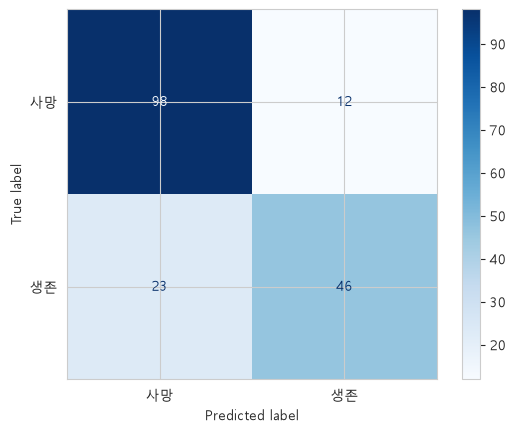

,Sex,Pclass,Age,SibSp,Parch,Fare,Embarked,실제,예측,생존 예측 확률,틀림
565,male,3,24.0,2,0,24.1500,S,0,0,0.069826,False
160,male,3,44.0,0,1,16.1000,S,0,0,0.049050,False
553,male,3,22.0,0,0,7.2250,C,1,0,0.154680,True
860,male,3,41.0,2,0,14.1083,S,0,0,0.036490,False
241,female,3,NaN,1,0,15.5000,Q,1,1,0.676683,False


In [3]:
display(y_test.value_counts().sort_index().rename(index={0: "사망", 1: "생존"})
        .rename("실제 인원(명)").to_frame())
print(f"모두 사망으로 예측한 정확도: {(y_test == 0).mean():.3f}")
baseline_metrics = pd.Series({
    "정확도": accuracy_score(y_test, y_pred),
    "정밀도": precision_score(y_test, y_pred),
    "재현율": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
}, name="기본 모델")
display(baseline_metrics.round(3).to_frame())
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["사망", "생존"], cmap="Blues"
)
plt.show()

results = df.loc[y_test.index, features].copy()
results["실제"] = y_test
results["예측"] = y_pred
results["생존 예측 확률"] = y_proba
results["틀림"] = results["실제"] != results["예측"]
display(results.head())

## 3. 어떤 예측이 궁금한가요?

[AI에게 처음 전달할 지침](https://app.notion.com/p/classification_practice-ipynb-3dbb39501c388037bac8f074f8418bf0)과 데이터 설명·준비 코드를 Continue에 전달하세요. 혼동행렬이나 결과표에서 궁금한 예측을 골라 자신의 말로 질문해 보세요.

받은 코드는 아래에 실행합니다. 해석을 물을 때는 실제 결과를, 오류가 나면 코드와 오류 메시지를 함께 전달하세요. 필요한 만큼 실행 셀을 추가해도 됩니다.

## 4. 왜 틀렸을까요? 무엇을 바꿔볼까요?

AI와 대화하며 관심 있는 사례를 살펴보세요. 발견한 차이를 바탕으로 무엇을 바꿀지 먼저 생각하고, 구현은 AI의 도움을 받으세요.

원본은 보존하고 한 번에 한 가지를 바꿉니다. 입력을 바꾸는 실험에서는 같은 모델과 판단 기준으로 비교하고, 실제 정답을 입력에 넣지 않습니다. 구간 등 데이터로 정하는 기준은 학습 자료에서 구합니다.

<details>
<summary>막힐 때만 보기 · 비교할 단서</summary>

- 같은 실제 라벨 안에서 맞춘 사람과 틀린 사람은 무엇이 다른가요? 종류별 인원·틀린 비율 표나 숫자 항목의 분포를 비교해 볼 수 있습니다.
- 발견한 특징이 학습 자료에서도 생존 여부를 구분하나요? 생존자와 사망자를 모두 포함해 인원과 생존 비율을 확인해 볼 수 있습니다.
- 그 특징은 모델에 이미 어떻게 들어가 있나요? 다르게 표현할 필요가 있을지 생각해 보세요. 차이가 보인다는 것만으로 원인이나 개선 효과가 확인된 것은 아닙니다.

</details>

## 5. 처음 궁금했던 문제가 줄었나요?

같은 평가 자료에서 변경 전후를 비교하세요. **처음 선택한 같은 사례·그룹의 오류**가 줄었는지, **전체 지표와 다른 오류**는 어떻게 달라졌는지 함께 확인합니다.

표나 그래프를 보여주며 **발견한 차이 → 바꾼 이유 → 실제 결과**를 짧게 설명하세요. 성능이 좋아지지 않아도 괜찮습니다.